In [23]:
# @title Importing Libraries

#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import pycountry_convert as pc
import folium
from folium.plugins import HeatMap
import shap
from scipy.spatial.distance import cdist
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [6]:
#Install libraries
!pip install prophet

In [22]:
!pip install pycountry_convert

In [24]:
#Read dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

In [25]:
# @title Data Cleaning and Preprocessing
#Analyze Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58853 entries, 0 to 58852
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       58853 non-null  object 
 1   location_name                 58853 non-null  object 
 2   latitude                      58853 non-null  float64
 3   longitude                     58853 non-null  float64
 4   timezone                      58853 non-null  object 
 5   last_updated_epoch            58853 non-null  int64  
 6   last_updated                  58853 non-null  object 
 7   temperature_celsius           58853 non-null  float64
 8   temperature_fahrenheit        58853 non-null  float64
 9   condition_text                58853 non-null  object 
 10  wind_mph                      58853 non-null  float64
 11  wind_kph                      58853 non-null  float64
 12  wind_degree                   58853 non-null  int64  
 13  w

In [6]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [7]:
df.tail()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
58848,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1742031900,2025-03-15 05:45,25.2,77.4,Partly cloudy,...,12.580,14.985,1,2,06:34 AM,06:38 PM,07:49 PM,07:19 AM,Waning Gibbous,99
58849,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1742031900,2025-03-15 16:45,26.4,79.5,Mist,...,60.680,65.860,3,8,06:05 AM,06:06 PM,07:00 PM,06:30 AM,Waning Gibbous,100
58850,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1742031900,2025-03-15 12:45,22.1,71.7,Sunny,...,30.525,160.580,2,3,06:11 AM,06:13 PM,07:13 PM,06:43 AM,Waning Gibbous,100
58851,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1742031900,2025-03-15 11:45,22.5,72.5,Patchy rain nearby,...,8.325,8.695,1,1,06:10 AM,06:21 PM,07:06 PM,06:54 AM,Waning Gibbous,100
58852,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1742031900,2025-03-15 11:45,22.4,72.4,Patchy rain nearby,...,4.440,4.810,1,1,05:59 AM,06:10 PM,06:53 PM,06:43 AM,Waning Gibbous,100


In [8]:
df.isnull().sum()

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


In [10]:
df.nunique()

,0
country,210
location_name,248
latitude,383
longitude,389
timezone,190
last_updated_epoch,599
last_updated,9844
temperature_celsius,650
temperature_fahrenheit,1071
condition_text,47


In [10]:
df.drop_duplicates(inplace=True)

In [9]:
#Statistics Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,58853.0,1.913685e+01,2.447627e+01,-4.130000e+01,3.750000e+00,1.725000e+01,4.040000e+01,6.415000e+01
longitude,58853.0,2.218545e+01,6.581278e+01,-1.752000e+02,-6.836100e+00,2.332000e+01,5.058000e+01,1.792200e+02
last_updated_epoch,58853.0,1.728964e+09,7.603974e+06,1.715849e+09,1.722514e+09,1.728985e+09,1.735555e+09,1.742032e+09
temperature_celsius,58853.0,2.220972e+01,9.633445e+00,-2.490000e+01,1.700000e+01,2.500000e+01,2.840000e+01,4.920000e+01
temperature_fahrenheit,58853.0,7.197910e+01,1.734001e+01,-1.280000e+01,6.260000e+01,7.700000e+01,8.320000e+01,1.206000e+02
wind_mph,58853.0,8.279575e+00,9.288884e+00,2.200000e+00,4.000000e+00,6.900000e+00,1.140000e+01,1.841200e+03
wind_kph,58853.0,1.332860e+01,1.494728e+01,3.600000e+00,6.500000e+00,1.120000e+01,1.840000e+01,2.963200e+03
wind_degree,58853.0,1.692119e+02,1.036532e+02,1.000000e+00,8.000000e+01,1.600000e+02,2.560000e+02,3.600000e+02
pressure_mb,58853.0,1.014127e+03,1.365299e+01,9.470000e+02,1.010000e+03,1.013000e+03,1.018000e+03,3.006000e+03
pressure_in,58853.0,2.994658e+01,4.031513e-01,2.796000e+01,2.983000e+01,2.992000e+01,3.005000e+01,8.877000e+01


In [10]:
#Seperate Categorical and Numerical Variables for easy analysis
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['country', 'location_name', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='object')
Numerical Variables:
['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination']


In [26]:
# @title Advanced EDA to analyze outliers
# Identify and Analyze Outliers
# Select numerical features for clustering

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)  # First quartile (25th percentile)
    Q3 = df[column].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile range

    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

#  Apply the function to numerical columns
numerical_columns = [
    'latitude', 'longitude', 'temperature_celsius', 'temperature_fahrenheit',
    'wind_mph', 'wind_kph', 'wind_degree', 'pressure_mb', 'pressure_in',
    'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
    'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index',
    'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
    'air_quality_gb-defra-index', 'moon_illumination'
]

# Remove outliers for each numerical column
df_cleaned = df.copy()
for column in numerical_columns:
    df_cleaned = remove_outliers_iqr(df_cleaned, column)

# Check the shape of the cleaned DataFrame
print("Original DataFrame Shape:", df.shape)
print("Cleaned DataFrame Shape:", df_cleaned.shape)

Original DataFrame Shape: (58853, 41)
Cleaned DataFrame Shape: (12896, 41)


In [58]:
# @title Forecasting with multiple models
# Forecasting with multiple models
# Convert 'last_updated' to datetime and set as index
df_cleaned = df_cleaned.reset_index()
df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])
df_cleaned.set_index('last_updated', inplace=True)

scaler = MinMaxScaler()
df_cleaned[numerical_columns] = scaler.fit_transform(df_cleaned[numerical_columns])


# Select the target variable (temperature_celsius)
target = 'temperature_celsius'
time_series = df_cleaned[target]

# Split the data into training and testing sets
train_size = int(len(time_series) * 0.8)
train, test = time_series[:train_size], time_series[train_size:]

forecast = np.zeros_like(test)

# Now you can proceed with scaling the test set
test = scaler.inverse_transform(test.reshape(-1, 1)).flatten()


# Evaluate Each Model
def evaluate_model(test, forecast, model_name):
    mae = mean_absolute_error(test, forecast)
    mse = mean_squared_error(test, forecast)
    rmse = np.sqrt(mse)
    print(f"{model_name} Metrics:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    return mae, mse, rmse

# Model 1: Exponential Smoothing (ETS)
def build_and_evaluate_ets(train, test):
    model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=365)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=len(test))  # Forecast for the test set
    metrics = evaluate_model(test, forecast, "Exponential Smoothing (ETS)")

    # Visualize the forecast
    plt.figure(figsize=(12, 6))
    plt.plot(test.index, test, label='Actual Data', color='black')
    plt.plot(test.index, forecast, label='ETS Forecast', color='blue')
    plt.title("Exponential Smoothing (ETS) Forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.show()

    return forecast, metrics

# Model 2: Prophet
def build_and_evaluate_prophet(train, test):
    train_df = train.reset_index()
    train_df = train_df.rename(columns={'last_updated': 'ds', target: 'y'})

    model = Prophet()
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model.fit(train_df)

    future = model.make_future_dataframe(periods=365)  # Forecast for the test set
    forecast = model.predict(future)
    forecast = forecast['yhat'][-len(test):]  # Ensure the forecast matches the test set length
    metrics = evaluate_model(test, forecast, "Prophet")

    # Visualize the forecast
    plt.figure(figsize=(12, 6))
    plt.plot(test.index, test, label='Actual Data', color='black')
    plt.plot(test.index, forecast, label='Prophet Forecast', color='green')
    plt.title("Prophet Forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.show()

    return forecast, metrics

# Model 3: ARIMA
def build_and_evaluate_arima(train, test):
    model = ARIMA(train, order=(5, 1, 0))  # ARIMA(p=5, d=1, q=0)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=len(test))  # Forecast for the test set
    metrics = evaluate_model(test, forecast, "ARIMA")

    # Visualize the forecast
    plt.figure(figsize=(12, 6))
    plt.plot(test.index, test, label='Actual Data', color='black')
    plt.plot(test.index, forecast, label='ARIMA Forecast', color='red')
    plt.title("ARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.show()

    return forecast, metrics

# Build and Evaluate Each Model Separately
print("Building and Evaluating ETS Model...")
ets_forecast, ets_metrics = build_and_evaluate_ets(train, test)

print("\nBuilding and Evaluating Prophet Model...")
prophet_forecast, prophet_metrics = build_and_evaluate_prophet(train, test)

print("\nBuilding and Evaluating ARIMA Model...")
arima_forecast, arima_metrics = build_and_evaluate_arima(train, test)

AttributeError: 'Series' object has no attribute 'reshape'

ETS Forecast:
 last_updated
2024-10-29 10:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 06:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 03:00:00    0.0
dtype: float64
Prophet Forecast:
 last_updated
2024-10-29 10:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 06:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 03:00:00    0.0
Name: yhat, dtype: float64
ARIMA Forecast:
 last_updated
2024-10-29 10:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 06:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 03:00:00    0.0
Name: predicted_mean, dtype: float64
last_updated
2024-10-29 10:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 06:00:00    0.0
2024-10-29 05:00:00    0.0
2024-10-29 03:00:00    0.0
dtype: float64
Ensemble Metrics:
MAE: 0.46656293027028056
MSE: 0.24977062577162704
RMSE: 0.4997705731349406


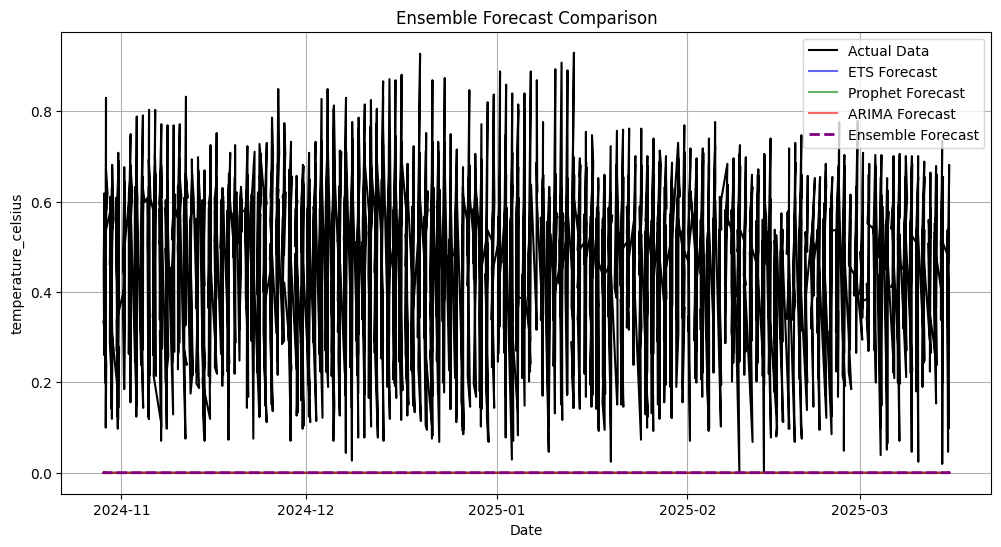

In [56]:
# @title Ensemble model
#Ensemble Method
# Combine Predictions Using a Weighted Average
# Define weights for each model (can be adjusted based on model performance)
weights = {'ETS': 0.2, 'Prophet': 0.1, 'ARIMA': 0.7}

print("ETS Forecast:\n", ets_forecast.head())
print("Prophet Forecast:\n", prophet_forecast.head())
print("ARIMA Forecast:\n", arima_forecast.head())


# Ensure all forecasts have the same index as the test set
ets_forecast = ets_forecast.reindex(test.index)
prophet_forecast = prophet_forecast.reindex(test.index)
arima_forecast = arima_forecast.reindex(test.index)

# Fill NaN values with 0 if any
ets_forecast.fillna(0, inplace=True)
prophet_forecast.fillna(0, inplace=True)
arima_forecast.fillna(0, inplace=True)


# Create the ensemble forecast
ensemble_forecast = (weights['ETS'] * ets_forecast +
                     weights['Prophet'] * prophet_forecast +
                     weights['ARIMA'] * arima_forecast)

print(ensemble_forecast.head())


# Evaluate the Ensemble Model
ensemble_metrics = evaluate_model(test, ensemble_forecast, "Ensemble")

ensemble_forecast.fillna(0, inplace=True)


# Visualize the Ensemble Forecast
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual Data', color='black')
plt.plot(test.index, ets_forecast, label='ETS Forecast', color='blue', alpha=0.6)
plt.plot(test.index, prophet_forecast, label='Prophet Forecast', color='green', alpha=0.6)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red', alpha=0.6)
plt.plot(test.index, ensemble_forecast, label='Ensemble Forecast', color='purple', linestyle='--', linewidth=2)
plt.title("Ensemble Forecast Comparison")
plt.xlabel("Date")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

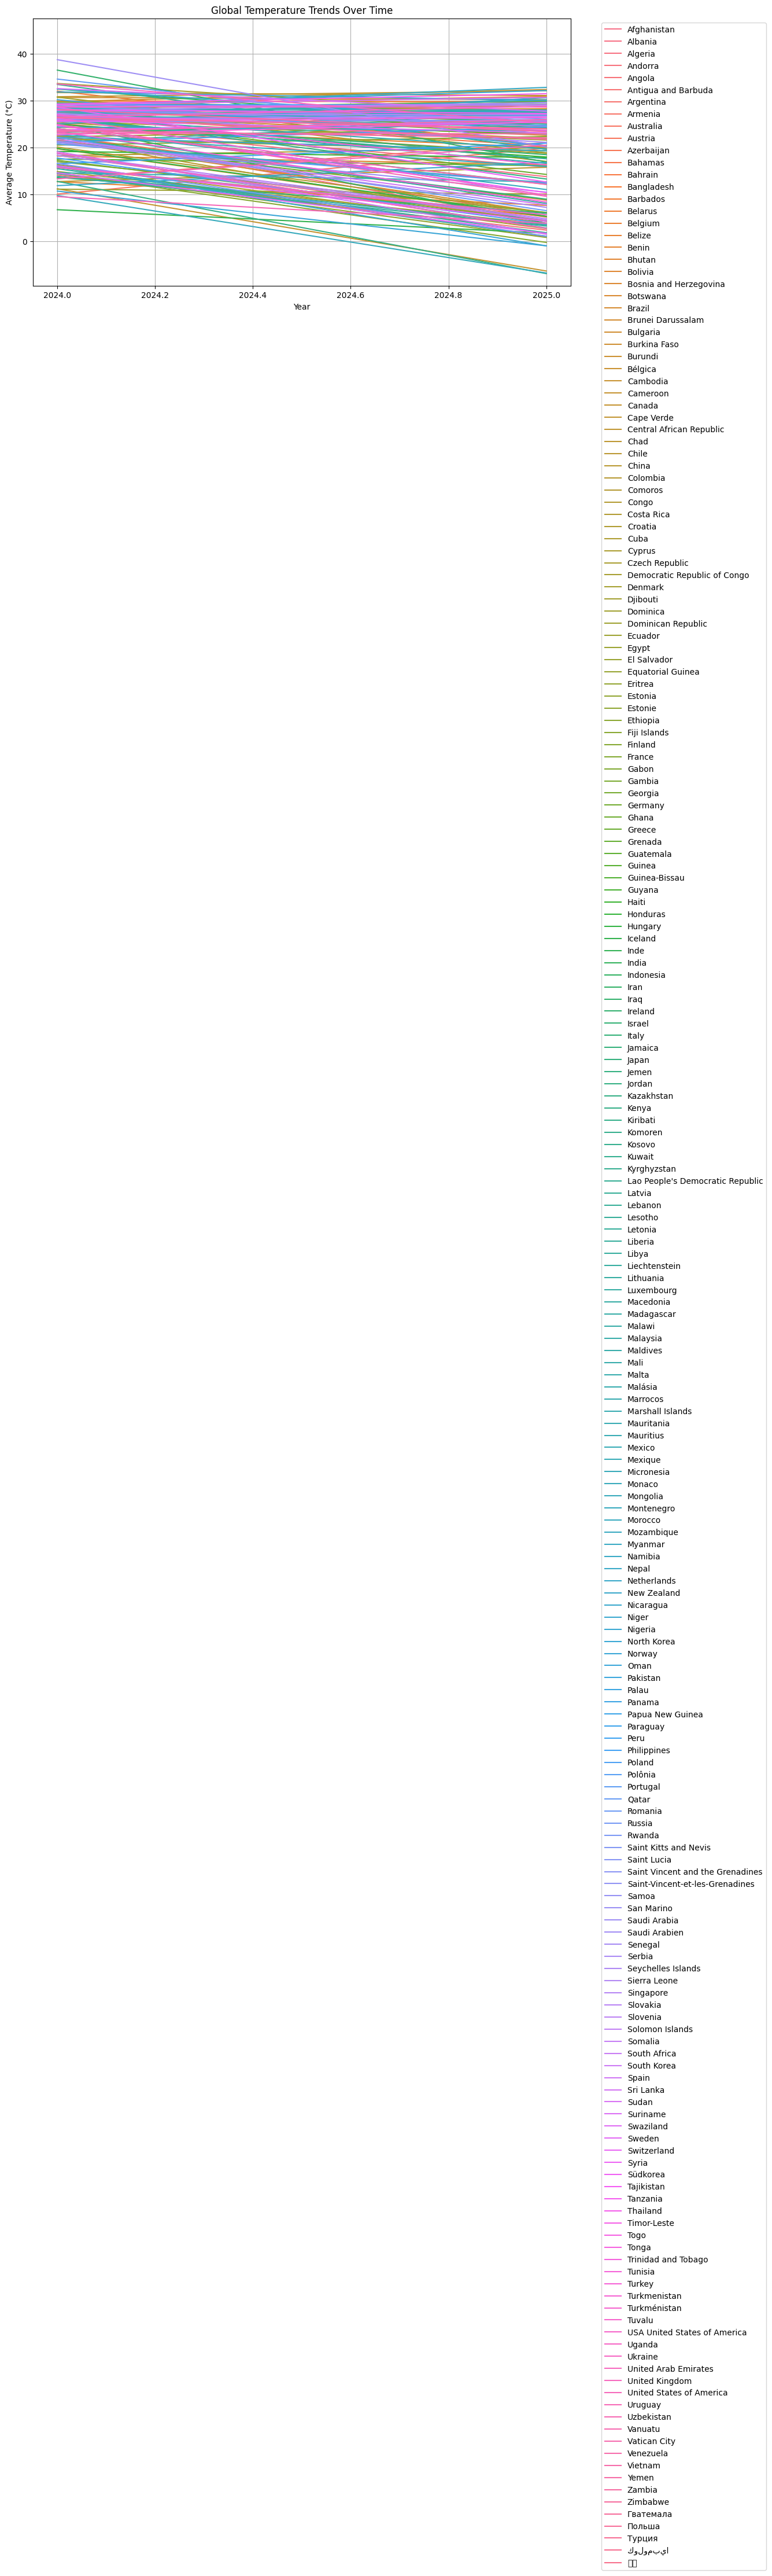

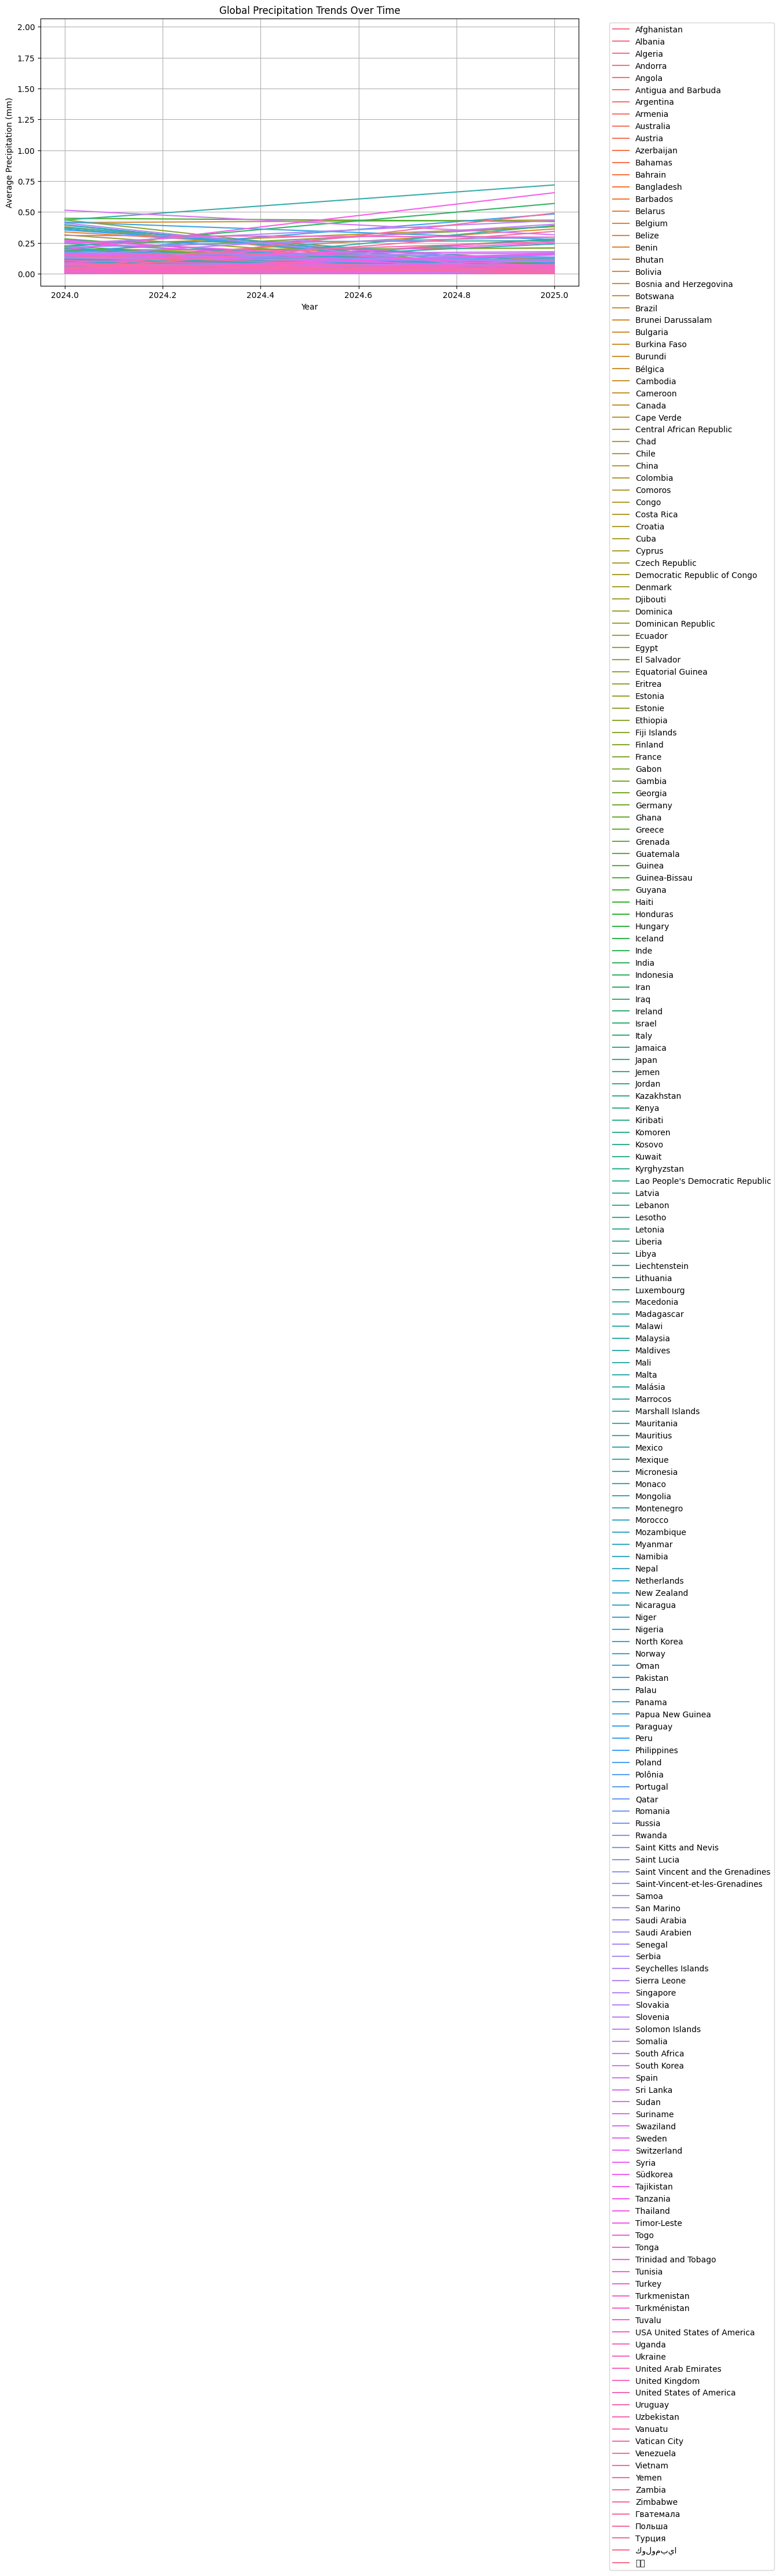

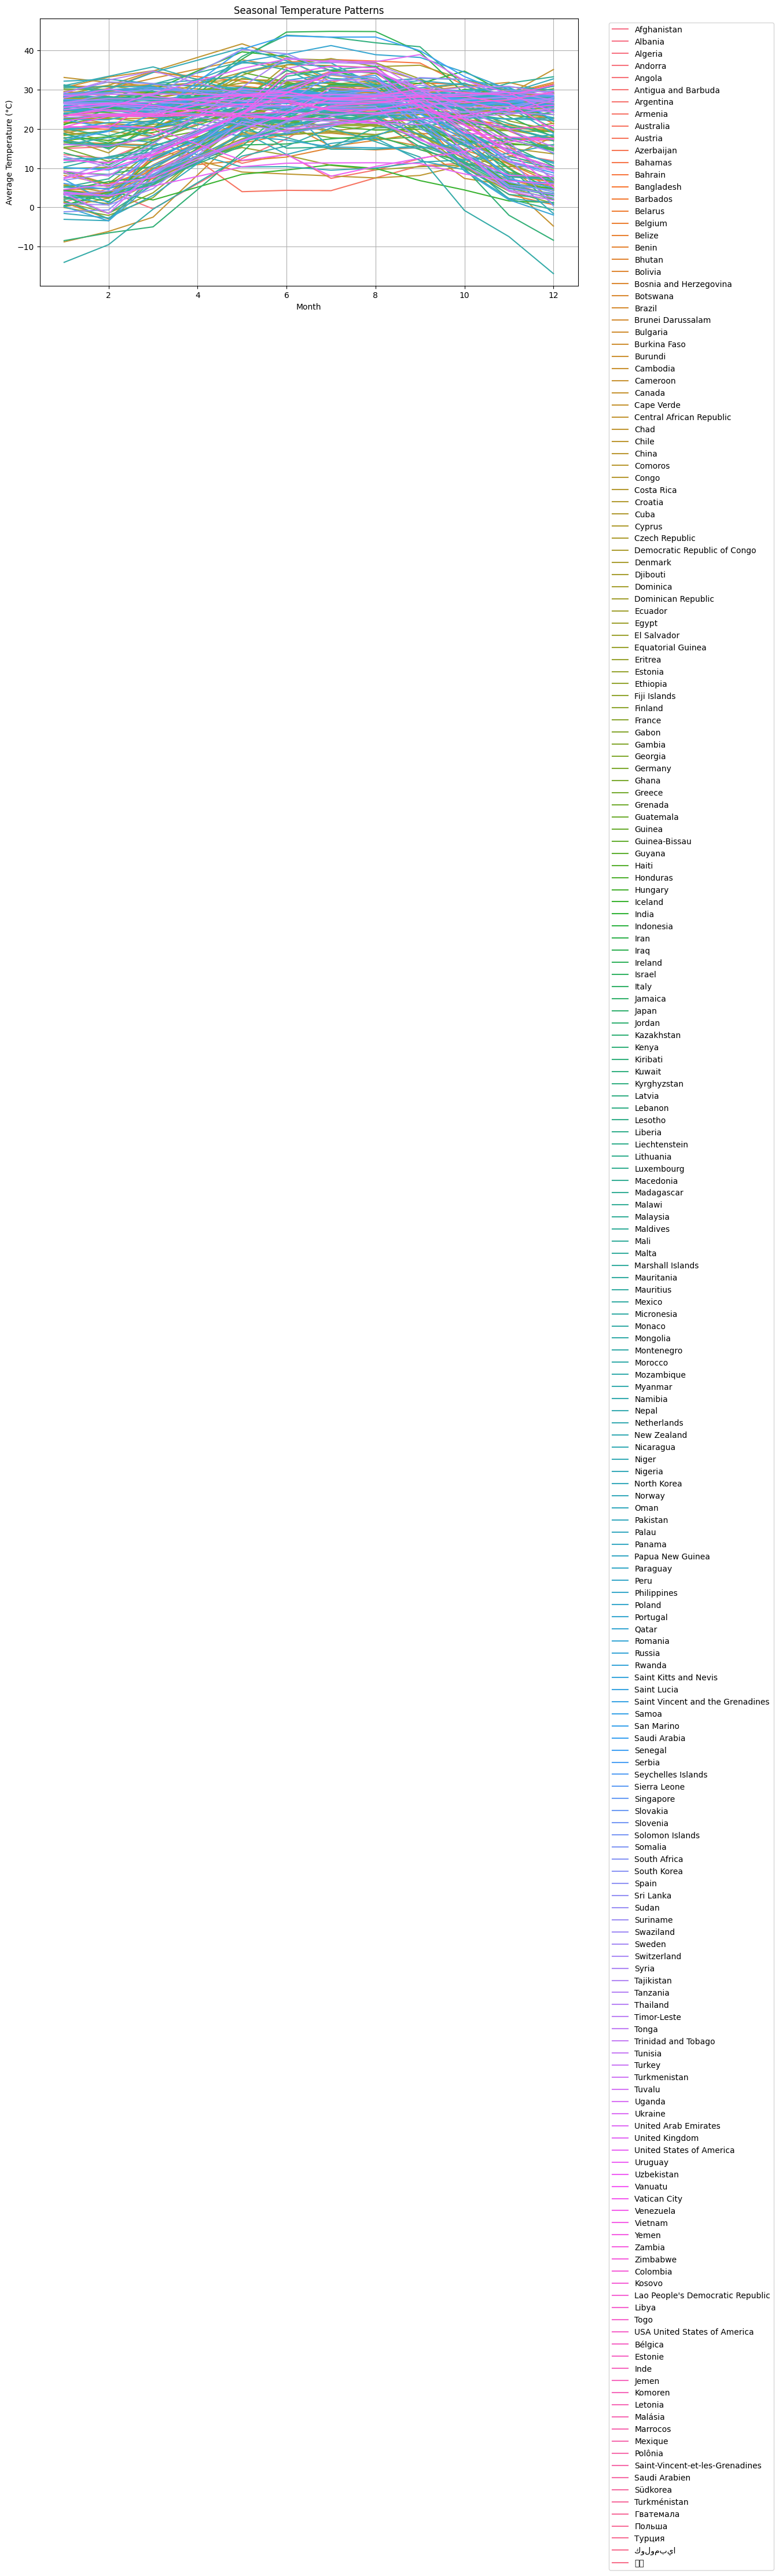

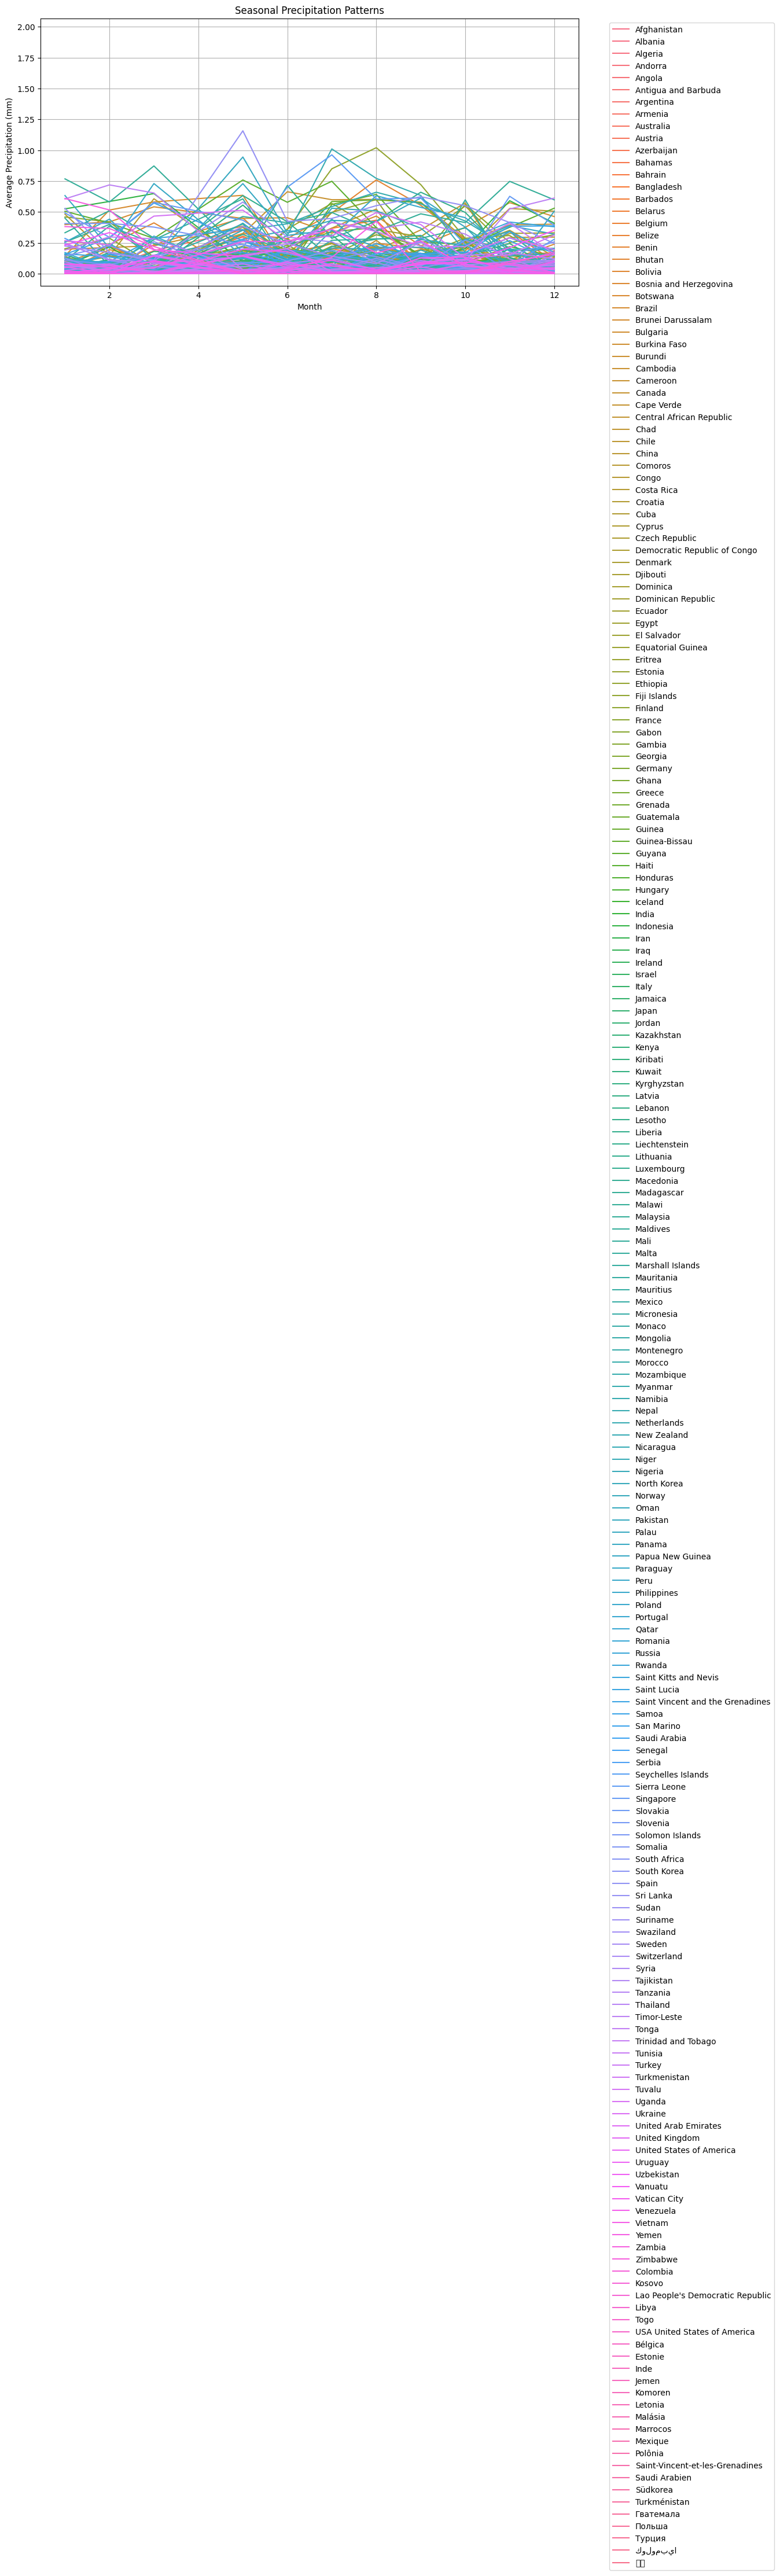

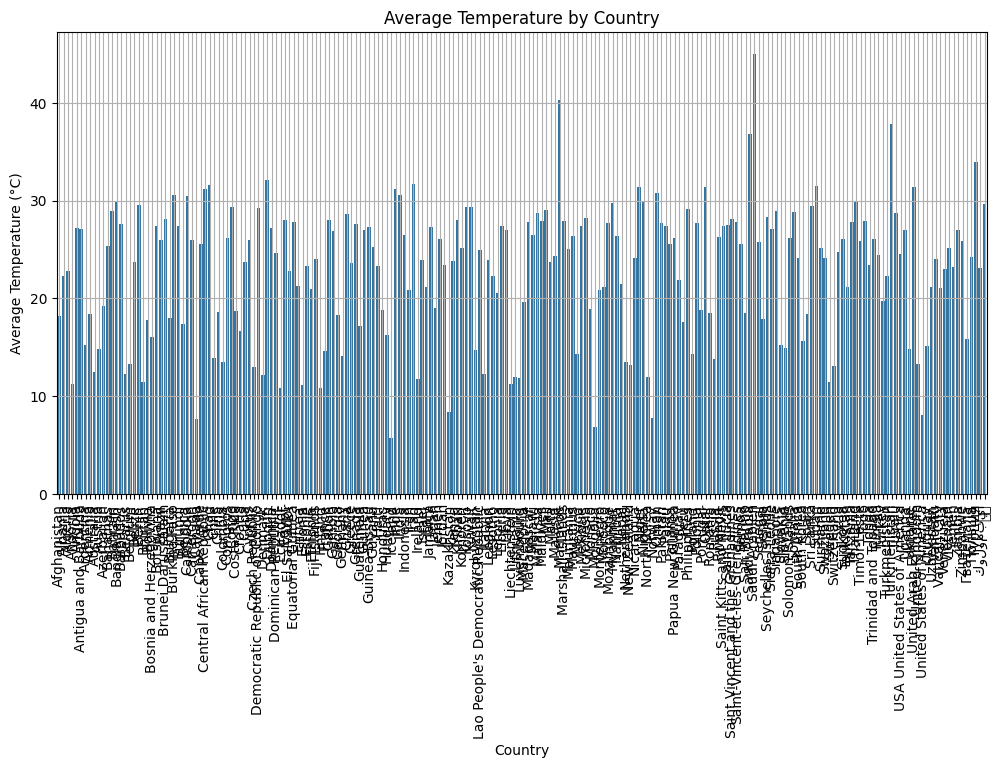

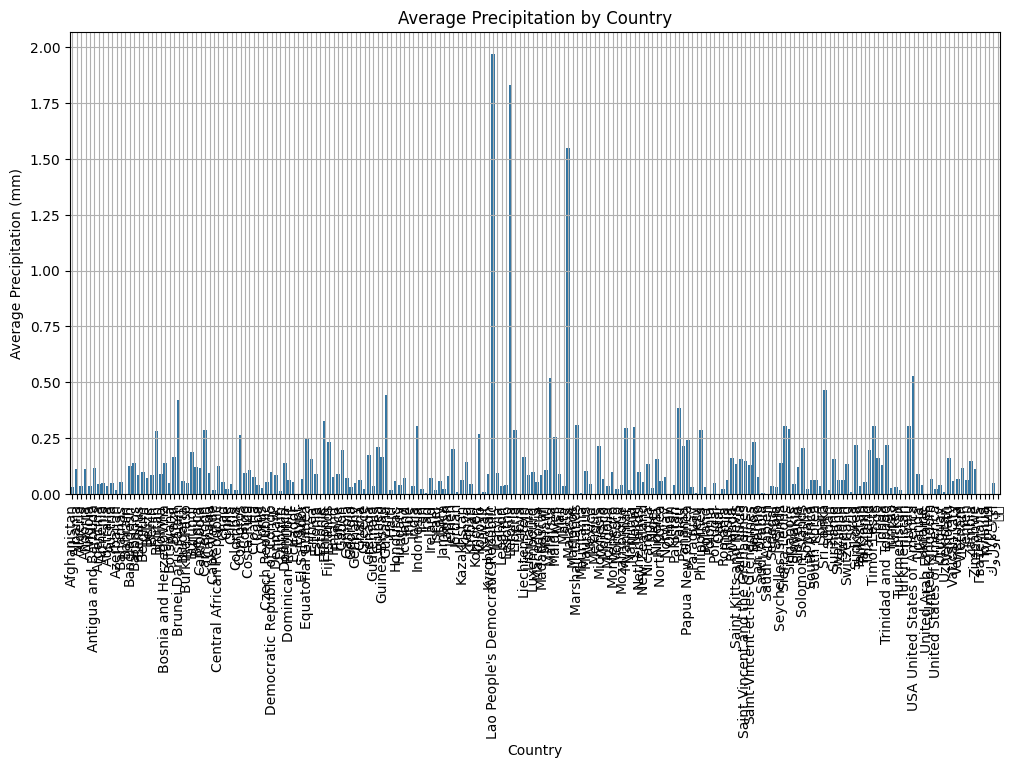

In [16]:
# @title Unique Analysis

#Climate Analysis
df = df.reset_index()
df['last_updated'] = pd.to_datetime(df['last_updated'])
df.set_index('last_updated', inplace=True)

# Extract year and month for aggregation
df['year'] = df.index.year
df['month'] = df.index.month

#  Analyze Long-Term Trends
# Aggregate data by year and region ( country)
yearly_trends = df.groupby(['year', 'country']).agg({
    'temperature_celsius': 'mean',
    'precip_mm': 'mean'
}).reset_index()

# Plot global temperature trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trends, x='year', y='temperature_celsius', hue='country', ci=None)
plt.title("Global Temperature Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Plot global precipitation trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trends, x='year', y='precip_mm', hue='country', ci=None)
plt.title("Global Precipitation Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Average Precipitation (mm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Study Seasonal Patterns
# Aggregate data by month and region ( country)
monthly_trends = df.groupby(['month', 'country']).agg({
    'temperature_celsius': 'mean',
    'precip_mm': 'mean'
}).reset_index()

# Plot seasonal temperature patterns
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends, x='month', y='temperature_celsius', hue='country', ci=None)
plt.title("Seasonal Temperature Patterns")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Plot seasonal precipitation patterns
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends, x='month', y='precip_mm', hue='country', ci=None)
plt.title("Seasonal Precipitation Patterns")
plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


# Compare temperature and precipitation across regions (e.g., countries)
region_comparison = df.groupby('country').agg({
    'temperature_celsius': 'mean',
    'precip_mm': 'mean'
}).reset_index()

# Plot average temperature by country
plt.figure(figsize=(12, 6))
sns.barplot(data=region_comparison, x='country', y='temperature_celsius')
plt.title("Average Temperature by Country")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# Plot average precipitation by country
plt.figure(figsize=(12, 6))
sns.barplot(data=region_comparison, x='country', y='precip_mm')
plt.title("Average Precipitation by Country")
plt.xlabel("Country")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

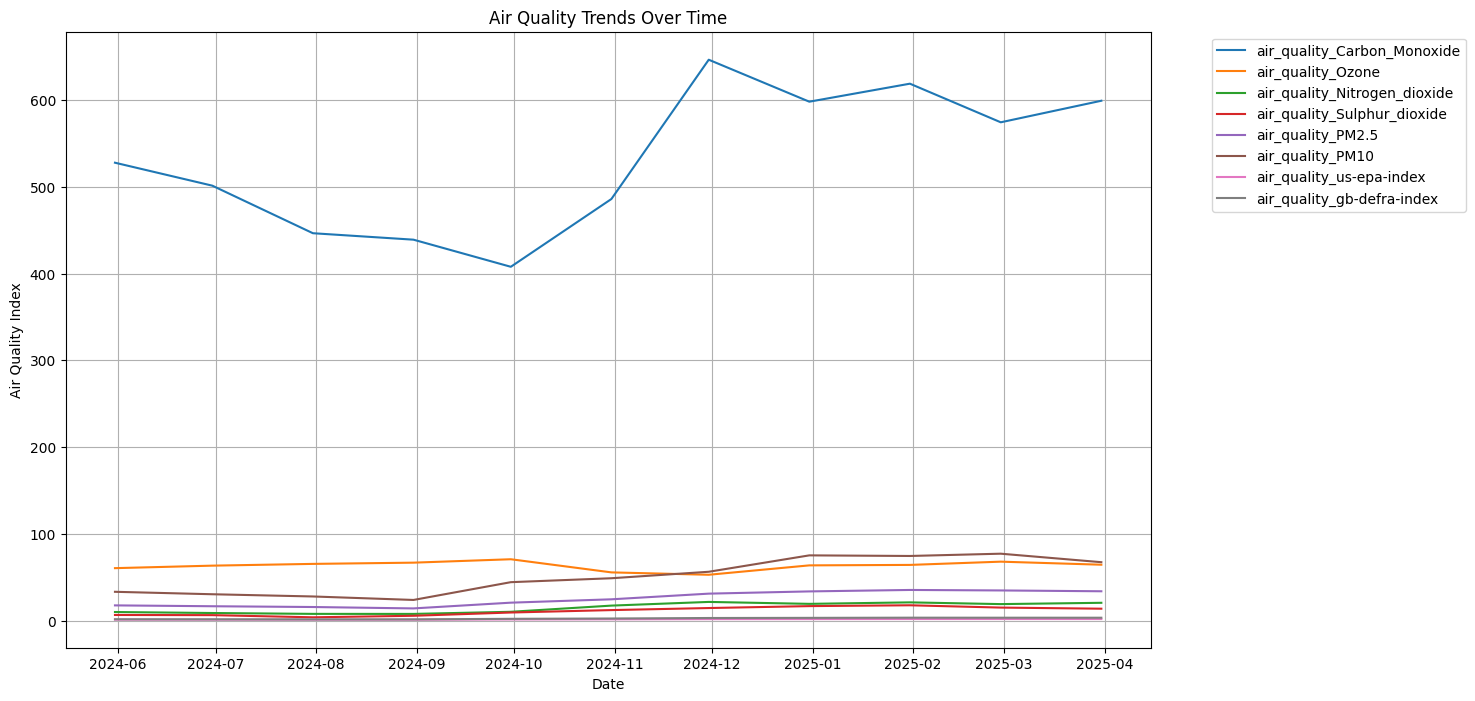

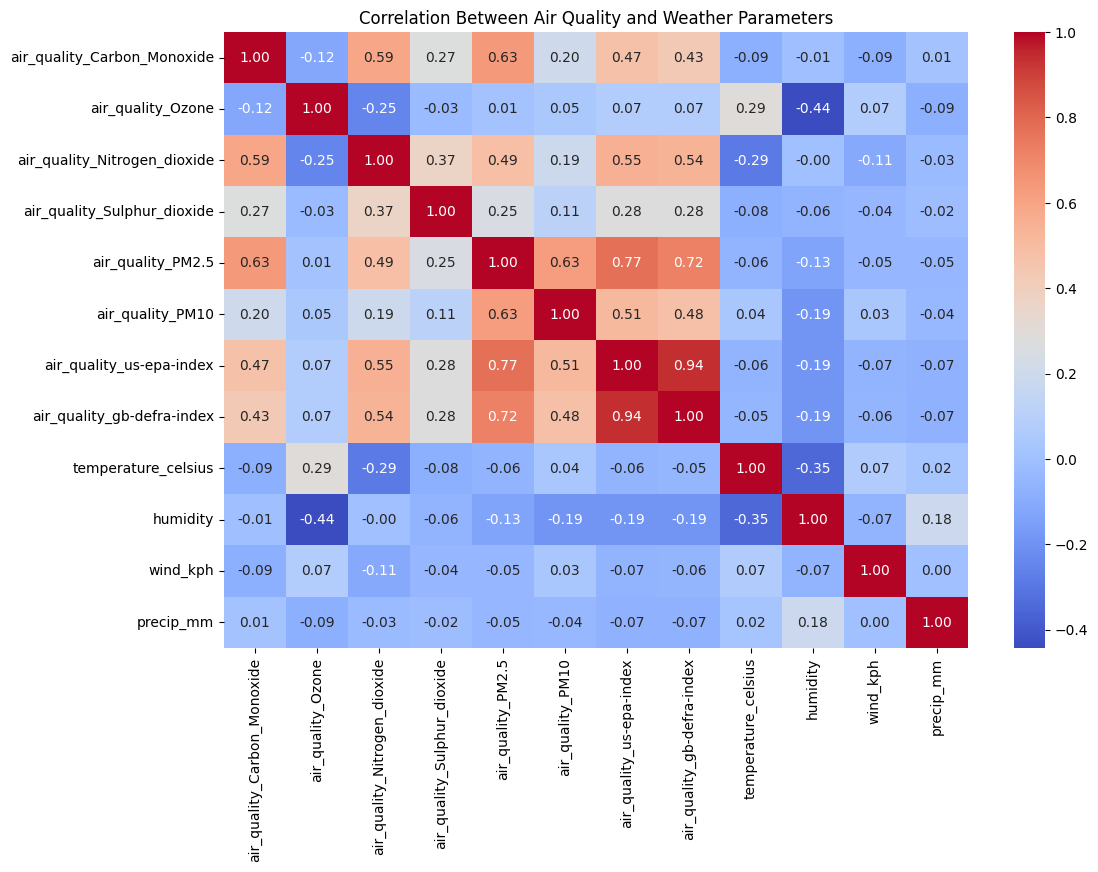

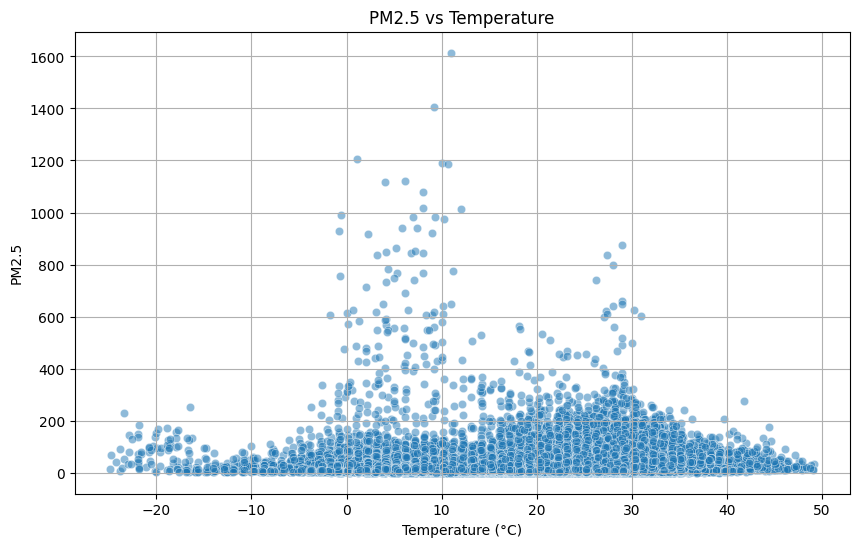

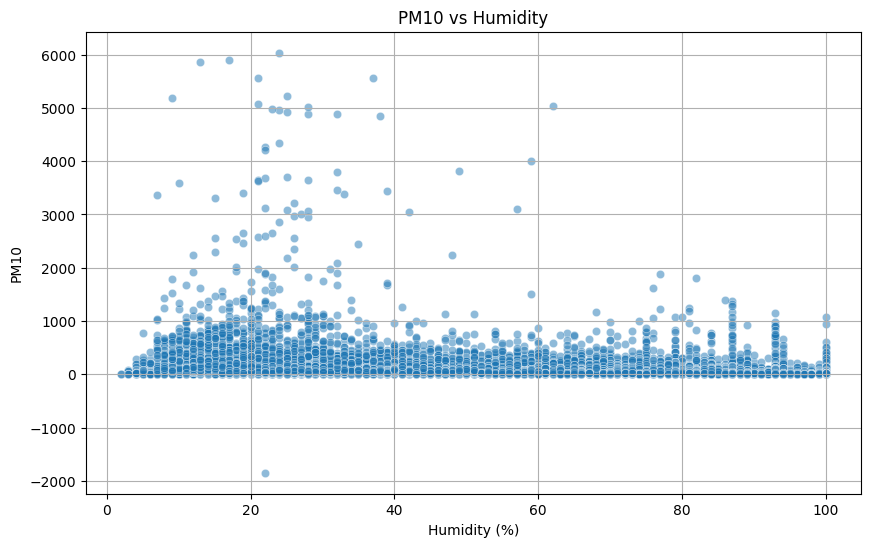

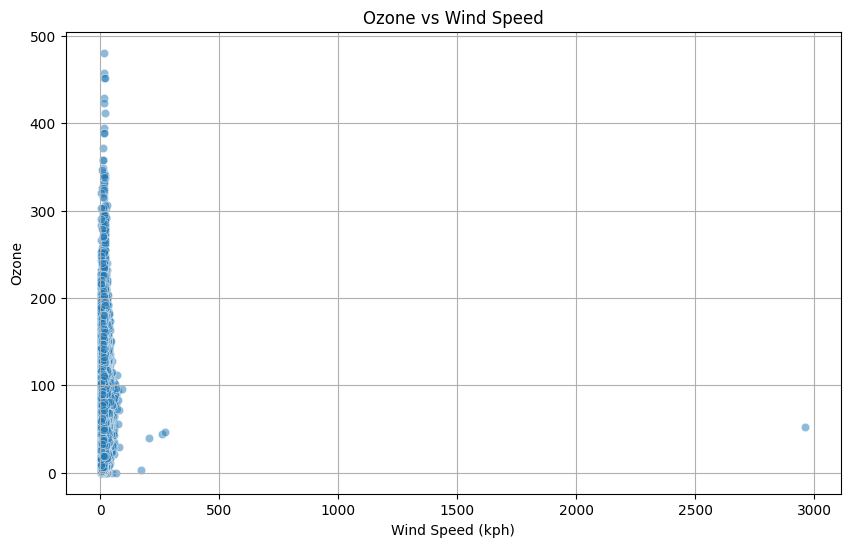

In [29]:
#Environmental Impact
# Convert 'last_updated' to datetime and set as index
df = df.reset_index()
df['last_updated'] = pd.to_datetime(df['last_updated'])
df.set_index('last_updated', inplace=True)

# Select relevant columns for air quality and weather parameters
air_quality_columns = [
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10',
    'air_quality_us-epa-index', 'air_quality_gb-defra-index'
]

weather_columns = [
    'temperature_celsius', 'humidity', 'wind_kph', 'precip_mm'
]

# Create a new DataFrame with selected columns
analysis_df = df[air_quality_columns + weather_columns]

# Analyze Air Quality Trends
# Resample air quality data to monthly averages
monthly_air_quality = analysis_df[air_quality_columns].resample('M').mean()

# Plot air quality trends over time
plt.figure(figsize=(14, 8))
for column in air_quality_columns:
    plt.plot(monthly_air_quality.index, monthly_air_quality[column], label=column)
plt.title("Air Quality Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Air Quality Index")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

#  Correlation Analysis
# Calculate correlation matrix between air quality and weather parameters
correlation_matrix = analysis_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Air Quality and Weather Parameters")
plt.show()

#  Analyze Specific Correlations
# Plot scatter plots for specific correlations
# Example: PM2.5 vs Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis_df, x='temperature_celsius', y='air_quality_PM2.5', alpha=0.5)
plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5")
plt.grid(True)
plt.show()

# Example: PM10 vs Humidity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis_df, x='humidity', y='air_quality_PM10', alpha=0.5)
plt.title("PM10 vs Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("PM10")
plt.grid(True)
plt.show()

# Example: Ozone vs Wind Speed
plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis_df, x='wind_kph', y='air_quality_Ozone', alpha=0.5)
plt.title("Ozone vs Wind Speed")
plt.xlabel("Wind Speed (kph)")
plt.ylabel("Ozone")
plt.grid(True)
plt.show()

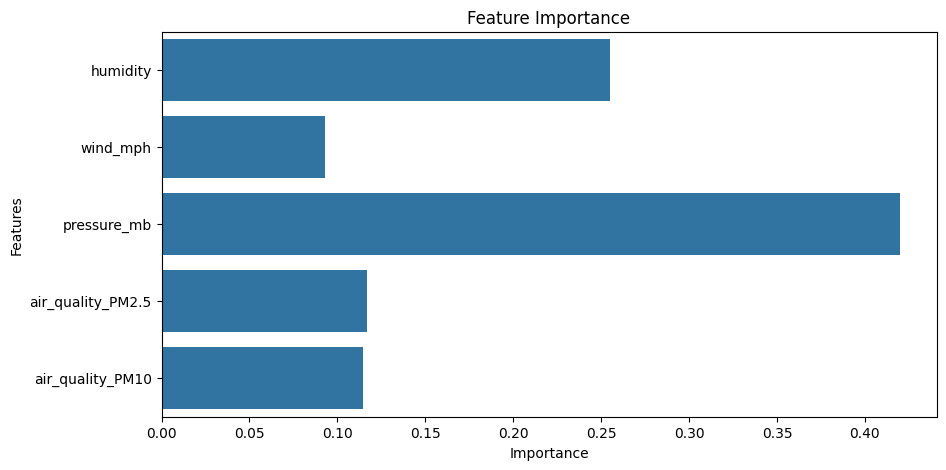

In [8]:
# Feature Importance
# Separate features and target
features = ['humidity', 'wind_mph', 'pressure_mb', 'air_quality_PM2.5', 'air_quality_PM10']
X = df[features].fillna(0)
y = df['temperature_celsius'].fillna(0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_

# Plot feature importances
plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()



In [12]:
#Spatial Analysis
fig = px.scatter_geo(df,
                     lat='latitude',
                     lon='longitude',
                     color='temperature_celsius',  # Color by temperature
                     hover_name='location_name',   # Show location name on hover
                     title='Geographical Distribution of Temperature',
                     scope='world',               # Set the map scope to the world
                     color_continuous_scale=px.colors.sequential.Plasma)

# Show the plot
fig.show()



# Create a base map
m = folium.Map(location=[20, 0], zoom_start=2)

# Add a heatmap for temperature
heat_data = [[row['latitude'], row['longitude'], row['temperature_celsius']] for index, row in df.iterrows()]
HeatMap(heat_data).add_to(m)

# Display the map
m


# Create a scatter plot on a map for humidity
fig = px.scatter_geo(df,
                     lat='latitude',
                     lon='longitude',
                     color='humidity',  # Color by humidity
                     hover_name='location_name',  # Show location name on hover
                     title='Geographical Distribution of Humidity',
                     scope='world',  # Set the map scope to the world
                     color_continuous_scale=px.colors.sequential.Plasma)

# Show the plot
fig.show()

         country  temperature_celsius   humidity   wind_mph  \
0    Afghanistan            18.194719  29.405941   6.762706   
1        Albania            22.274587  50.633663   6.298680   
2        Algeria            22.858609  57.572848   8.962252   
3        Andorra            11.232343  60.627063   5.610561   
4         Angola            27.056436  70.544554   7.365017   
..           ...                  ...        ...        ...   
205    Гватемала            15.900000  95.000000   4.000000   
206       Польша            24.200000  56.000000   8.500000   
207       Турция            34.000000  44.000000  15.000000   
208     كولومبيا            23.100000  95.000000   4.000000   
209           火鸡            29.700000  24.000000  11.400000   

     air_quality_Carbon_Monoxide  
0                     773.151155  
1                     277.008416  
2                     331.360099  
3                     186.577977  
4                     644.000165  
..                           ... 

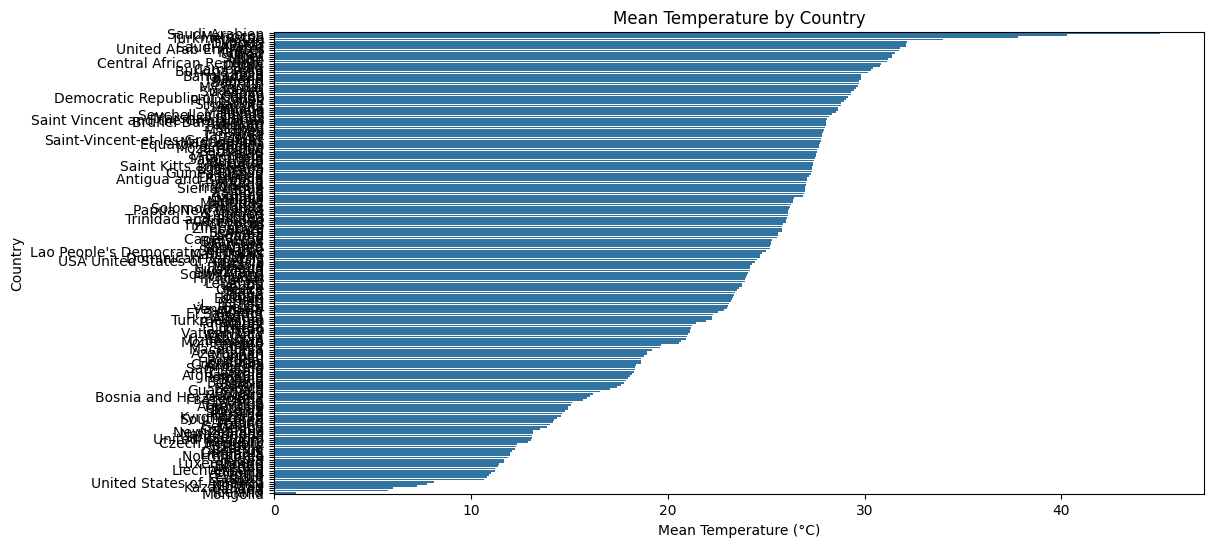

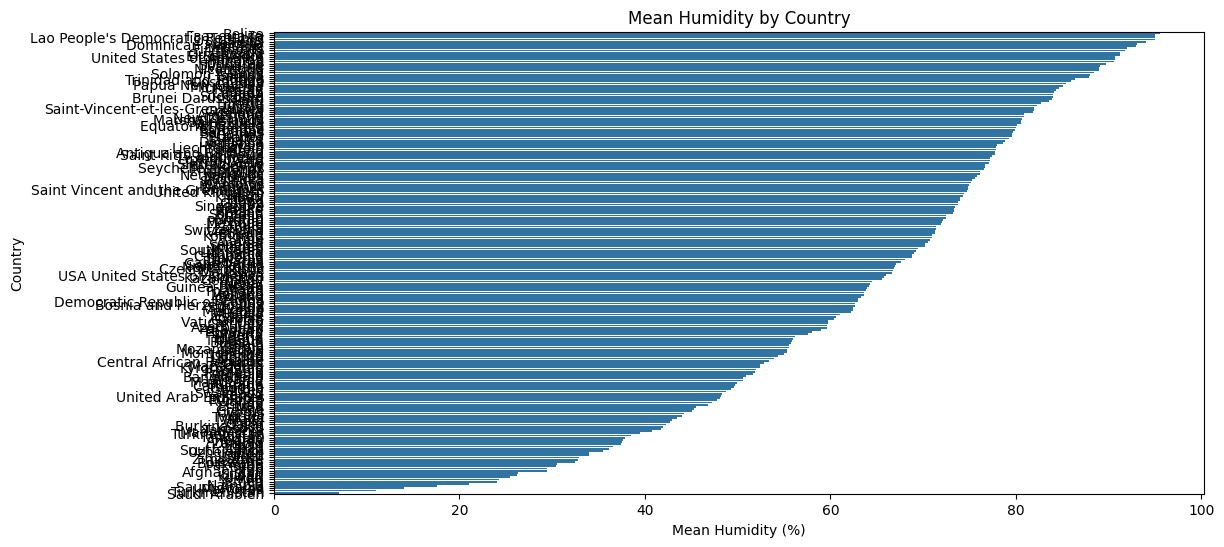

            country continent
0       Afghanistan      Asia
1           Albania    Europe
2           Algeria    Africa
3           Andorra    Europe
4            Angola    Africa
...             ...       ...
11577      Südkorea      None
11581       Bélgica      None
11588  Turkménistan      None
11592            火鸡      None
11597         Jemen      None

[210 rows x 2 columns]


In [18]:
# Group by country and calculate mean weather conditions
weather_by_country = df.groupby('country').agg({
    'temperature_celsius': 'mean',
    'humidity': 'mean',
    'wind_mph': 'mean',
    'air_quality_Carbon_Monoxide': 'mean'
}).reset_index()

# Display the aggregated data
print(weather_by_country)

# Plot mean temperature by country
plt.figure(figsize=(12, 6))
sns.barplot(x='temperature_celsius', y='country', data=weather_by_country.sort_values('temperature_celsius', ascending=False))
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Country')
plt.title('Mean Temperature by Country')
plt.show()

# Plot mean humidity by country
plt.figure(figsize=(12, 6))
sns.barplot(x='humidity', y='country', data=weather_by_country.sort_values('humidity', ascending=False))
plt.xlabel('Mean Humidity (%)')
plt.ylabel('Country')
plt.title('Mean Humidity by Country')
plt.show()

import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name, cn_name_format="default")
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return None

# Add a continent column to the DataFrame
df['continent'] = df['country'].apply(country_to_continent)

# Display the DataFrame with the new continent column
print(df[['country', 'continent']].drop_duplicates())

       continent  temperature_celsius   humidity   wind_mph  \
0         Africa            27.040787  53.381743   8.982864   
1           Asia            23.802873  53.515482   7.930707   
2         Europe            14.973144  65.485976   8.483666   
3  North America            22.644832  84.572300   7.971893   
4        Oceania            24.243298  83.495312  10.655571   
5  South America            18.878312  78.291863   4.888087   

   air_quality_Carbon_Monoxide  
0                   384.154568  
1                   936.220469  
2                   343.448938  
3                   412.583041  
4                   193.392280  
5                   742.000836  


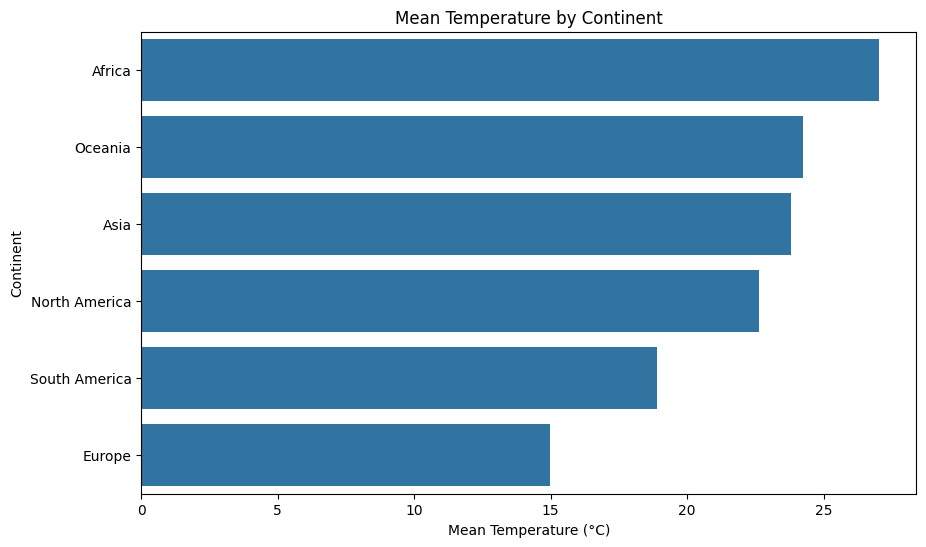

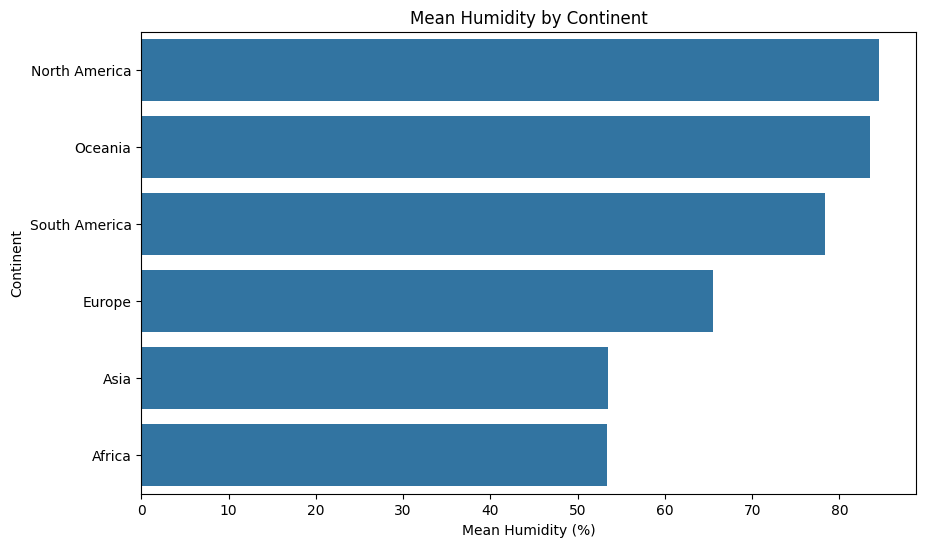

In [20]:
# Group by continent and calculate mean weather conditions
weather_by_continent = df.groupby('continent').agg({
    'temperature_celsius': 'mean',
    'humidity': 'mean',
    'wind_mph': 'mean',
    'air_quality_Carbon_Monoxide': 'mean'
}).reset_index()

# Display the aggregated data
print(weather_by_continent)

plt.figure(figsize=(10, 6))
sns.barplot(x='temperature_celsius', y='continent', data=weather_by_continent.sort_values('temperature_celsius', ascending=False))
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Continent')
plt.title('Mean Temperature by Continent')
plt.show()

# Plot mean humidity by continent
plt.figure(figsize=(10, 6))
sns.barplot(x='humidity', y='continent', data=weather_by_continent.sort_values('humidity', ascending=False))
plt.xlabel('Mean Humidity (%)')
plt.ylabel('Continent')
plt.title('Mean Humidity by Continent')
plt.show()